# Add VI morphology labels for DR2 sample

In [1]:
import requests

from astropy.table import Table
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
from astropy.coordinates import SkyCoord
import astropy.units as u

import numpy as np

import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
import matplotlib.image as mpimg

from pathlib import Path

import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
# ### To start out with the full catalog
# SGA = Table.read('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v3.fits')
# SGA['SGA_ID'] = SGA['SGA_ID'].astype(int)
# SGA["morphology_VI"] = np.full(len(SGA), "Unknown") #initialize as unknowns
# SGA["morphology_VI"][SGA['D26'] < 1] = 'NA' #store small galaxies as NA so we don't need to worry about them

## If resuming classifications, read in the current level of completion
SGA = Table.read("/pscratch/sd/s/sgmoore1/TF/DR2_TF_VI_morphology.fits")

Text(0, 0.5, 'Count')

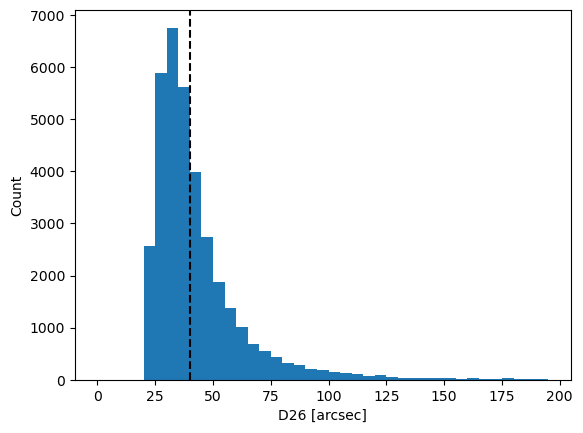

In [3]:
plt.figure()
plt.hist(60*SGA['D26'], bins = np.arange(0,200,5))
plt.axvline(x=40, color='k', ls='dashed')
plt.xlabel('D26 [arcsec]')
plt.ylabel('Count')


In [4]:
np.unique(SGA["morphology_VI"], return_counts=True)

(<Column name='morphology_VI' dtype='bytes7' length=5>
      NA
 Unknown
 irregul
 neither
  spiral,
 array([30809,  4656,    21,     5,   175]))

# Generate cutouts
These only need to be generated once, but I have been doing in batches

In [5]:
def get_cutout(sgaid, ra, dec, size, verbose=False):
    """Grab and cache legacy survey cutouts.
    
    Parameters
    ----------
    sgaid : int
        SGA galaxy ID.
    ra : float
        Right ascension (degrees).
    dec : float
        Declination (degrees).
    verbose : bool
        Add some status messages if true.
        
    Returns
    -------
    img_name : str
        Name of JPG cutout file written after query.
    w : astropy.wcs.WCS
        World coordinate system for the image.
    """
    # Either load an existing image or download a cutout.
    img_name = '/pscratch/sd/s/sgmoore1/TF/cache/sga_{}.jpg'.format(sgaid)
    
    if os.path.exists(img_name):
        if verbose:
            print('{} exists.'.format(img_name))
    else:
        img_url = 'https://www.legacysurvey.org/viewer/cutout.jpg?ra={}&dec={}&zoom=14&layer=ls-dr9&size={}&sga'.format(ra, dec, size)
        if verbose:
            print('Get {}'.format(img_url))
            
        with open(img_name, 'wb') as handle: 
            response = requests.get(img_url, stream=True) 
            if not response.ok: 
                print(response) 
            for block in response.iter_content(1024): 
                if not block: 
                    break 
                handle.write(block)
                
    # Set up the WCS.
    wcs_input_dict = {
        'CTYPE1': 'RA---TAN',
        'CUNIT1': 'deg',
        'CDELT1': -0.262/3600,
        'CRPIX1': size/2 + 0.5,
        'CRVAL1': ra,
        'NAXIS1': size,
        'CTYPE2': 'DEC--TAN',
        'CUNIT2': 'deg',
        'CDELT2': 0.262/3600,
        'CRPIX2': size/2 + 0.5,
        'CRVAL2': dec,
        'NAXIS2': size
    }
    w = WCS(wcs_input_dict)
    
    return img_name, w

In [6]:
# for i in range(len(SGA)):
    
#     # Retrieve SGA ID of galaxy
#     sga_id = SGA['SGA_ID'][i]
    
#     # Coordinates of SGA galaxy's center   
#     ra, dec, z = float(SGA['RA'][i]), float(SGA['DEC'][i]), float(SGA['Z_DESI'][i])
    
#     # D26 in arcmin
#     d26 = SGA['D26'][i]
    
#     #---------------------------------------------------------------------------
#     # Pad the image cutout of the galaxy.
#     # Multiply by 60 (to arcsec), divide by 180 to get pixscale.
#     npix = np.minimum(int(1.025 * d26*60/0.262), 512)
    
#     img_file, wcs = get_cutout(sga_id, ra, dec, size=npix, verbose=True)

# Make code for storing galaxy classifications

In [7]:
def show_galaxy():

    out.clear_output(wait=True)

    # Find the next unclassified galaxy
    unknown = np.where(SGA["morphology_VI"] == "Unknown")[0]

    if len(unknown) == 0:
        with out:
            print("All galaxies have been classified!")
        return

    current_index = int(unknown[0])
    row = SGA[current_index]

    sgaid = row["SGA_ID"]
    z = row["Z_DESI"]
    ra = row['RA']
    dec = row['DEC']
    # d26 = row["D26"]

    # npix = np.minimum(int(1.025 * d26*60/0.262), 512)
    # imgfile, wcs = get_cutout(sga_id, ra, dec, size=npix, verbose=True)

    imgfile = f"/pscratch/sd/s/sgmoore1/TF/cache/sga_{sgaid}.jpg"

    with out:

        fig, ax = plt.subplots(figsize=(7,7))

        if os.path.exists(imgfile):
            ax.imshow(mpimg.imread(imgfile))
        else:
            ax.text(
                0.5, 0.5,
                "Image not found",
                ha="center",
                va="center",
                fontsize=14
            )

        ax.axis("off")

        n_done = np.count_nonzero(SGA["morphology_VI"] != "Unknown")

        ax.set_title(
            # f"Completed: {n_done}/{len(SGA)}\n"
            f"SGA_ID = {sgaid} z = {z:.4f} RA = {row['RA']:.3f} DEC = {row['DEC']:.3f}"
        )

        plt.show()

    status.value = (
        f"<b>{n_done}</b> classified &nbsp;&nbsp; "
        f"<b>{len(unknown)}</b> remaining"
    )



def submit_clicked(b):

    # Find the current galaxy
    unknown = np.where(SGA["morphology_VI"] == "Unknown")[0]

    if len(unknown) == 0:
        return

    current_index = int(unknown[0])

    # Save the classification
    SGA["morphology_VI"][current_index] = classification.value

    # Display the next galaxy
    show_galaxy()

In [8]:
# Widgets

out = widgets.Output()

classification = widgets.RadioButtons(
    options=["spiral", "irregular", "neither"],
    description="Class:"
)

submit = widgets.Button(
    description="Submit",
    button_style="success",
    icon="check"
)

status = widgets.HTML()

# -------------------------------------------------------------------------
# Display interface
# -------------------------------------------------------------------------
submit.on_click(submit_clicked)

display(
    widgets.VBox([
        out,
        classification,
        submit,
        status
    ])
)

show_galaxy()

In [9]:
# for first iteration, do this to make a simpler catalog, trivial for later iterations
morphologies = SGA[['SGA_ID', 'RA', 'DEC', 'Z_DESI', 'D26', 'morphology_VI']]

In [10]:
np.unique(SGA['morphology_VI'], return_counts=True)

(<Column name='morphology_VI' dtype='bytes7' length=5>
      NA
 Unknown
 irregul
 neither
  spiral,
 array([30809,  4577,    29,    10,   241]))

In [11]:
morphologies.write("/pscratch/sd/s/sgmoore1/TF/DR2_TF_VI_morphology.fits",
          overwrite=True)

In [12]:
!chgrp desi /pscratch/sd/s/sgmoore1/TF/DR2_TF_VI_morphology.fits #ensures permissions stay accessible for next person
!chgrp -R desi /pscratch/sd/s/sgmoore1/TF/cache #make sure all cutout images are accessible

chgrp: changing group of '/pscratch/sd/s/sgmoore1/TF/cache/.ipynb_checkpoints/sga_13398-checkpoint.jpg': Operation not permitted
chgrp: changing group of '/pscratch/sd/s/sgmoore1/TF/cache/.ipynb_checkpoints/dist_2228.0-checkpoint.png': Operation not permitted
chgrp: changing group of '/pscratch/sd/s/sgmoore1/TF/cache/.ipynb_checkpoints/sga_24563-checkpoint.jpg': Operation not permitted
chgrp: changing group of '/pscratch/sd/s/sgmoore1/TF/cache/.ipynb_checkpoints': Operation not permitted
chgrp: changing group of '/pscratch/sd/s/sgmoore1/TF/cache/irrs/dist_193270.png': Operation not permitted
chgrp: changing group of '/pscratch/sd/s/sgmoore1/TF/cache/irrs/dist_749011.png': Operation not permitted
chgrp: changing group of '/pscratch/sd/s/sgmoore1/TF/cache/irrs/dist_595734.png': Operation not permitted
chgrp: changing group of '/pscratch/sd/s/sgmoore1/TF/cache/irrs/dist_689654.png': Operation not permitted
chgrp: changing group of '/pscratch/sd/s/sgmoore1/TF/cache/irrs/dist_248228.png': O